In [47]:
import pandas as pd
import numpy as np
import re

In [48]:
url = "https://raw.githubusercontent.com/Sahdam/Yield-Curve-Analysis-FGN-BOND-/main/Government_Securities_in_Excel%20(1).csv"
df = pd.read_csv(url, encoding='latin1')

In [49]:
df.head()

,auctionDate,securityType,tenor,auctionNo,auction,week,maturityDate,totalSubscription,totalSuccessful,rangeBid,successfulBidRates,rateDescription,rate,trueYield,amtOffered,totalAmtRepaid,netType,netValue
0,04/03/2026,NTB,91DAY,04-03-2026 91DAY,Primary Market,1st Week,04/06/2026,80923.856,64269.8540,14.8000 - 18.0000,14.800 - 15.9500,Issue,15.95,0.0000,100000.0000,0.0000,Sales,64269.8540
1,04/03/2026,NTB,182DAY,04-03-2026 182DAY,Primary Market,1st Week,03/09/2026,136539.824,91434.5230,15.0000 -18.8000,15.0000 - 16.6500,Issue,16.65,0.0000,150000.0000,0.0000,Sales,91434.5230
2,04/03/2026,NTB,364DAY,04-03-2026 364DAY,Primary Market,1st Week,04/03/2027,2126819.307,856034.5120,15.0000 - 22.0000,15.0000 - 16.7300,Issue,16.73,0.0000,80000.0000,0.0000,Sales,856034.5120
3,03/03/2026,OMO,7DAY,03-03-2026 7DAY,OMO,1st Week,10/03/2026,56000.000,0.0000,22.5000 - 23.0000,0.0000,Issue,0.00,0.0000,200000.0000,0.0000,Sales,0.0000
4,03/03/2026,OMO,98DAY,03-03-2026 98DAY,OMO,1st Week,09/06/2026,104250.000,62000.0000,19.3400 - 20.7700,19.3400 - 19.3500,Issue,19.35,0.0000,200000.0000,0.0000,Sales,62000.0000


In [50]:
df["tenor"].unique()

array(['91DAY', '182DAY', '364DAY', '7DAY', '98DAY', '105DAY', '207DAY',
       '354DAY', '208DAY', '348DAY', '203DAY', '161DAY', '210DAY',
       '168DAY', '162DAY', '211DAY', '180DAY', '215DAY', '174DAY',
       '188DAY', '175DAY', '152DAY', '173DAY', '56DAY', '81DAY', '91 DAY',
       '196DAY', '252DAY', '193DAY', '249DAY', '109DAY', '151DAY',
       '85DAY', '99DAY', '120DAY', '88DAY', '102DAY', '123DAY', '84DAY',
       '245DAY', '204DAY', '363DAY', '260DAY', '155DAY', '106DAY',
       '232DAY', '104DAY', '139DAY', '169DAY', '315DAY', '329DAY',
       '350DAY', '298DAY', '319DAY', '355DAY', '362DAY', '183 DAY',
       '347DAY', '361DAY', '358DAY', '365DAY', '90 DAY', '181 DAY',
       '363 DAY', '182 DAY', '364 DAY', '351DAY', '186DAY', '95DAY',
       '179DAY', '89 DAY', '187 DAY', '362 DAY', '193 DAY', '361 DAY',
       '96 DAY', '194 DAY', '365 DAY', '85 DAYS', '92DAY', '176DAY',
       '81 Day', '179 Day', '347 Day', '109 DAY', '186 DAY', '354 DAY',
       '188 DAY', '105 DAYS

In [51]:
df['securityType'].unique()

array(['NTB', 'OMO', 'OMOM', 'FGN BOND', 'FGN BONDS', 'FGN Bonds',
       'FGB BONDS', 'FGN BODS', 'OMO ', 'omo', 'FGN Bond', 'NT Bonds',
       'Others', 'Bonds', 'Nigerian Saving Certificate',
       'CBN Certificate'], dtype=object)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4634 entries, 0 to 4633
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   auctionDate         4634 non-null   object 
 1   securityType        4634 non-null   object 
 2   tenor               4634 non-null   object 
 3   auctionNo           4634 non-null   object 
 4   auction             4634 non-null   object 
 5   week                4634 non-null   object 
 6   maturityDate        4634 non-null   object 
 7   totalSubscription   4634 non-null   float64
 8   totalSuccessful     4634 non-null   object 
 9   rangeBid            4634 non-null   object 
 10  successfulBidRates  4634 non-null   object 
 11  rateDescription     4634 non-null   object 
 12  rate                4634 non-null   float64
 13  trueYield           4634 non-null   object 
 14  amtOffered          4634 non-null   object 
 15  totalAmtRepaid      4634 non-null   object 
 16  netTyp

In [53]:
df.isnull().sum()

,0
auctionDate,0
securityType,0
tenor,0
auctionNo,0
auction,0
week,0
maturityDate,0
totalSubscription,0
totalSuccessful,0
rangeBid,0


In [54]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (4634, 18)

Columns: ['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week', 'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid', 'successfulBidRates', 'rateDescription', 'rate', 'trueYield', 'amtOffered', 'totalAmtRepaid', 'netType', 'netValue']

First 3 rows:
   auctionDate securityType   tenor          auctionNo         auction  \
0  04/03/2026          NTB   91DAY   04-03-2026 91DAY  Primary Market   
1  04/03/2026          NTB  182DAY  04-03-2026 182DAY  Primary Market   
2  04/03/2026          NTB  364DAY  04-03-2026 364DAY  Primary Market   

       week maturityDate  totalSubscription totalSuccessful  \
0  1st Week   04/06/2026          80923.856      64269.8540   
1  1st Week   03/09/2026         136539.824      91434.5230   
2  1st Week   04/03/2027        2126819.307     856034.5120   

            rangeBid successfulBidRates rateDescription   rate trueYield  \
0  14.8000 - 18.0000   14.800 - 15.9500           Issue  15.95    0.0000   


In [55]:
def clean_security_type(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    if 'FGN' in s and ('BOND' in s or 'BOD' in s):
        return 'FGN BOND'
    elif s in ['NTB']:
        return 'NTB'
    elif 'OMO' in s:
        return 'OMO'
    elif 'NT BOND' in s or s == 'BONDS':
        return 'FGN BOND'
    else:
        return s


In [56]:
df['security_type_clean'] = df['securityType'].apply(clean_security_type)

print(df['security_type_clean'].value_counts())

security_type_clean
NTB                            2573
OMO                            1532
FGN BOND                        508
CBN CERTIFICATE                  10
OTHERS                            7
NIGERIAN SAVING CERTIFICATE       3
FGB BONDS                         1
Name: count, dtype: int64


In [57]:
df['auction_date'] = pd.to_datetime(df['auctionDate'], dayfirst=True, errors='coerce')
df['maturity_date'] = pd.to_datetime(df['maturityDate'], dayfirst=True, errors='coerce')

df['tenor_days'] = (df['maturity_date'] - df['auction_date']).dt.days

print("\nTenor range:")
print(df['tenor_days'].describe())
print("\nNegative or zero tenors:", (df['tenor_days'] <= 0).sum())


Tenor range:
count     4634.000000
mean       559.311610
std       1763.952839
min       -309.000000
25%         92.000000
50%        182.000000
75%        355.000000
max      66475.000000
Name: tenor_days, dtype: float64

Negative or zero tenors: 21


In [58]:
def classify_tenor(days):
    if pd.isna(days) or days <= 0:
        return np.nan
    elif days <= 100:
        return '91D'
    elif days <= 200:
        return '182D'
    elif days <= 400:
        return '364D'
    elif days <= 600:
        return '2Y'        # ~547 days
    elif days <= 1200:
        return '3Y'        # ~1095 days
    elif days <= 2000:
        return '5Y'        # ~1825 days
    elif days <= 2800:
        return '7Y'        # ~2555 days
    elif days <= 4000:
        return '10Y'       # ~3650 days
    elif days <= 6000:
        return '15Y'       # ~5475 days
    elif days <= 8000:
        return '20Y'       # ~7300 days
    elif days <= 11000:
        return '25Y'       # ~9125 days
    else:
        return '30Y'       # ~10950 days



In [59]:
df['tenor_bucket'] = df['tenor_days'].apply(classify_tenor)
print("\nTenor bucket counts:")
print(df['tenor_bucket'].value_counts().sort_index())


Tenor bucket counts:
tenor_bucket
10Y      104
15Y       24
182D    1518
20Y       70
25Y       40
2Y         4
30Y        2
364D    1086
3Y        73
5Y       115
7Y        46
91D     1531
Name: count, dtype: int64


In [60]:
df_clean = df[df['security_type_clean'].isin(['NTB', 'FGN BOND'])].copy()

In [61]:
standard_tenors = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y',
                   '15Y', '20Y', '25Y', '30Y']
df_clean = df_clean[df_clean['tenor_bucket'].isin(standard_tenors)]

In [62]:
print("\nCleaned dataset shape:", df_clean.shape)
print("\nDate range:", df_clean['auction_date'].min(),
      "to", df_clean['auction_date'].max())


Cleaned dataset shape: (3067, 23)

Date range: 2001-04-17 00:00:00 to 2026-03-04 00:00:00


In [63]:
df_clean.head(10)

,auctionDate,securityType,tenor,auctionNo,auction,week,maturityDate,totalSubscription,totalSuccessful,rangeBid,...,trueYield,amtOffered,totalAmtRepaid,netType,netValue,security_type_clean,auction_date,maturity_date,tenor_days,tenor_bucket
0,04/03/2026,NTB,91DAY,04-03-2026 91DAY,Primary Market,1st Week,04/06/2026,80923.856,64269.8540,14.8000 - 18.0000,...,0.0000,100000.0000,0.0000,Sales,64269.8540,NTB,2026-03-04,2026-06-04,92,91D
1,04/03/2026,NTB,182DAY,04-03-2026 182DAY,Primary Market,1st Week,03/09/2026,136539.824,91434.5230,15.0000 -18.8000,...,0.0000,150000.0000,0.0000,Sales,91434.5230,NTB,2026-03-04,2026-09-03,183,182D
2,04/03/2026,NTB,364DAY,04-03-2026 364DAY,Primary Market,1st Week,04/03/2027,2126819.307,856034.5120,15.0000 - 22.0000,...,0.0000,80000.0000,0.0000,Sales,856034.5120,NTB,2026-03-04,2027-03-04,365,364D
6,04/02/2026,NTB,91DAY,05-02-2026 91DAY,Primary Market,1st Week,07/05/2026,66050.846,63213.8460,14.5000 - 20.0000,...,0.0000,150000.0000,0.0000,Sales,63213.8460,NTB,2026-02-04,2026-05-07,92,91D
7,04/02/2026,NTB,182DAY,05-02-2026 182DAY,Primary Market,1st Week,06/08/2026,123407.708,80609.7070,15.6000 - 20.0300,...,0.0000,200000.0000,0.0000,Sales,80609.7070,NTB,2026-02-04,2026-08-06,183,182D
8,04/02/2026,NTB,364DAY,05-02-2026 364DAY,Primary Market,1st Week,04/02/2027,4396832.675,808784.1090,16.0000 - 21.0000,...,0.0000,800000.0000,0.0000,Sales,808784.1090,NTB,2026-02-04,2027-02-04,365,364D
15,07/01/2026,NTB,91DAY,07-01-2026 91DAY,Primary Market,2nd Week,09/04/2026,112263.000,108107.0000,15.0000 - 16.0000,...,0.0000,150000.0000,0.0000,Sales,108107.0000,NTB,2026-01-07,2026-04-09,92,91D
16,07/01/2026,NTB,182DAY,07-01-2026 182DAY,Primary Market,2nd Week,09/07/2026,49910.111,48230.1110,15.8500 - 17.2500,...,0.0000,200000.0000,0.0000,Sales,48230.1110,NTB,2026-01-07,2026-07-09,183,182D
17,07/01/2026,NTB,364DAY,07-01-2026 364DAY,Primary Market,2nd Week,07/01/2027,1380775.870,987784.8700,16.4200 - 21.0000,...,0.0000,800000.0000,0.0000,Sales,987784.8700,NTB,2026-01-07,2027-01-07,365,364D
24,17/12/2025,NTB,91DAY,17-12-2025 91DAY,Primary Market,3rd Week,19/03/2026,100626.463,100013.9630,14.8500 - 17.0000,...,0.0000,100000.0000,0.0000,Sales,100013.9630,NTB,2025-12-17,2026-03-19,92,91D


In [64]:
df.columns

Index(['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week',
       'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid',
       'successfulBidRates', 'rateDescription', 'rate', 'trueYield',
       'amtOffered', 'totalAmtRepaid', 'netType', 'netValue',
       'security_type_clean', 'auction_date', 'maturity_date', 'tenor_days',
       'tenor_bucket'],
      dtype='object')

In [65]:
print("\nAll columns:", df_clean.columns.tolist())

df_clean = df_clean.rename(columns={'rate': 'yield_pct'})

df_clean['yield_pct'] = pd.to_numeric(df_clean['yield_pct'], errors='coerce')


All columns: ['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week', 'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid', 'successfulBidRates', 'rateDescription', 'rate', 'trueYield', 'amtOffered', 'totalAmtRepaid', 'netType', 'netValue', 'security_type_clean', 'auction_date', 'maturity_date', 'tenor_days', 'tenor_bucket']


In [66]:
yield_curve = df_clean.pivot_table(
    index='auction_date',
    columns='tenor_bucket',
    values='yield_pct',
    aggfunc='mean'
)


In [67]:
col_order = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y',
             '10Y', '15Y', '20Y', '25Y', '30Y']
yield_curve = yield_curve.reindex(
    columns=[c for c in col_order if c in yield_curve.columns]
)

In [68]:
print("\nYield curve table (first 5 rows):")
print(yield_curve.head())
print("\nShape:", yield_curve.shape)


Yield curve table (first 5 rows):
tenor_bucket    91D   182D  364D  2Y    3Y  5Y  7Y  10Y  15Y  20Y  25Y  30Y
auction_date                                                               
2001-04-17      NaN    NaN   NaN NaN  21.5 NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-03      NaN  20.75   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-04    20.30    NaN   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-10      NaN  21.00   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-11    20.75    NaN   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN

Shape: (1482, 12)


In [69]:
yield_curve.head()

tenor_bucket,91D,182D,364D,2Y,3Y,5Y,7Y,10Y,15Y,20Y,25Y,30Y
auction_date,,,,,,,,,,,,
2001-04-17,NaN,NaN,NaN,NaN,21.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-03,NaN,20.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-04,20.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-10,NaN,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-11,20.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
yield_curve.std()

,0
tenor_bucket,
91D,5.176880
182D,5.318094
364D,4.743987
2Y,5.868986
3Y,2.468953
5Y,2.494010
7Y,2.331955
10Y,2.184866
15Y,3.099511


In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("=== Before cleaning ===")
print(yield_curve.describe())

yield_curve_clean = yield_curve.copy()
yield_curve_clean[yield_curve_clean < 1.0] = np.nan

print("\n=== After removing zeros ===")
print(yield_curve_clean.describe())


yield_curve_filled = yield_curve_clean.copy()
yield_curve_filled = yield_curve_filled.ffill(limit=7)


periods = {
    'Pre-Crisis (2001–2008)':      ('2001-01-01', '2008-12-31'),
    'Post-Crisis (2009–2015)':     ('2009-01-01', '2015-12-31'),
    'Recession Period (2016–2017)':('2016-01-01', '2017-12-31'),
    'Stability (2018–2021)':       ('2018-01-01', '2021-12-31'),
    'Hiking Cycle (2022–2024)':    ('2022-01-01', '2024-12-31'),
}


yield_curve_clean['slope_1Y_3M'] = (
    yield_curve_clean['364D'] - yield_curve_clean['91D']
)

yield_curve_clean['slope_10Y_3M'] = (
    yield_curve_clean['10Y'] - yield_curve_clean['91D']
)

print("\n=== Slope Statistics ===")
print(yield_curve_clean[['slope_1Y_3M', 'slope_10Y_3M']].describe())

# ── STEP 5: RESAMPLE TO MONTHLY (cleaner for visualisation) ───────────
yield_monthly = yield_curve_clean.resample('ME').mean()

print("\n=== Monthly dataset ===")
print(f"Shape: {yield_monthly.shape}")
print(f"Date range: {yield_monthly.index.min()} to {yield_monthly.index.max()}")
print(yield_monthly.head(10))

=== Before cleaning ===
tenor_bucket         91D        182D        364D         2Y         3Y  \
count         1072.00000  811.000000  523.000000   2.000000  73.000000   
mean             8.91078   10.042645   11.403890  18.850000  10.533871   
std              5.17688    5.318094    4.743987   5.868986   2.468953   
min              0.00000    0.000000    0.000000  14.700000   4.860000   
25%              4.80000    6.440000    8.985000  16.775000   9.200000   
50%              9.10000    9.450000   11.049000  18.850000  10.500000   
75%             13.50000   13.860000   14.225000  20.925000  12.000000   
max             22.25000   22.500000   23.500000  23.000000  21.500000   

tenor_bucket         5Y         7Y         10Y        15Y        20Y  \
count         114.00000  45.000000  101.000000  24.000000  69.000000   
mean           12.76322  13.009416   13.558882  11.573542  13.545145   
std             2.49401   2.331955    2.184866   3.099511   2.539762   
min             4.000

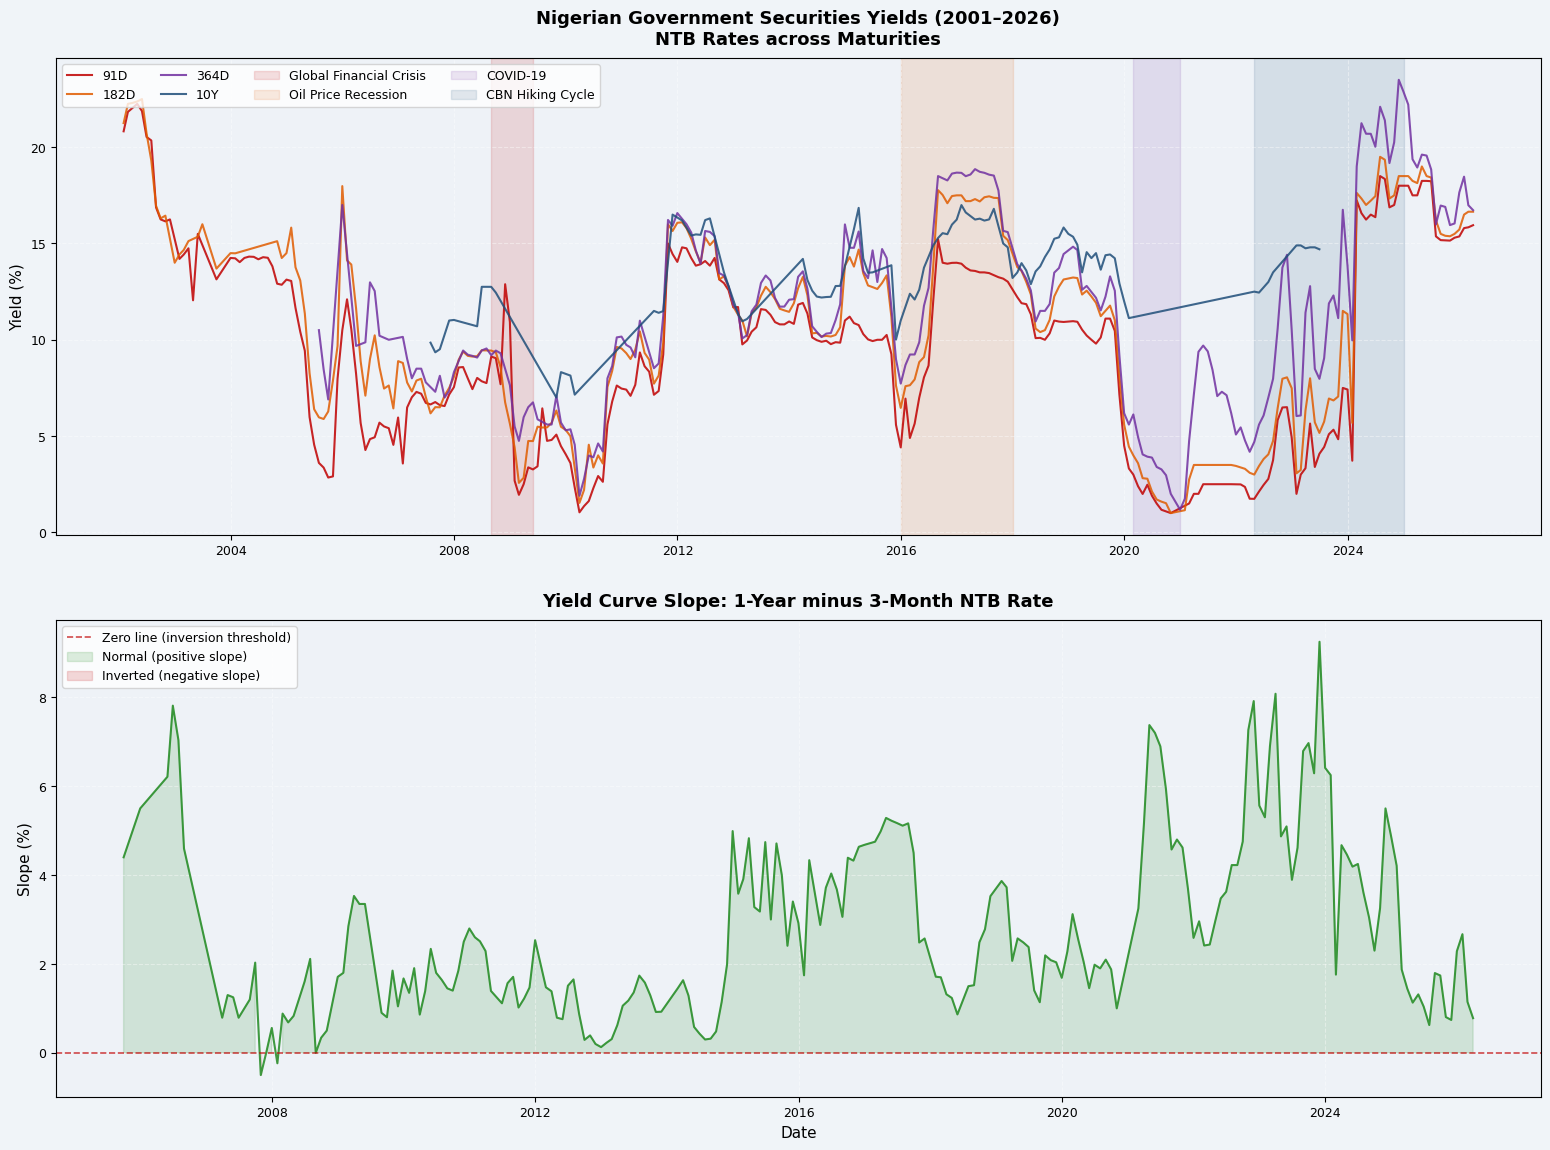

Chart saved.


In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── FIGURE 1: Full time series (equivalent to CMT chart) ──────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#f0f4f8')

# Updated colors dictionary to match actual column names
colors = {'91D': '#c00000', '182D': '#e05c00',
          '364D': '#7030a0', '10Y': '#1f4e79'}

# Top panel — yield levels
ax1 = axes[0]
ax1.set_facecolor('#eef2f7')
ax1.grid(True, linestyle='--', alpha=0.4, color='white')

# Updated column names in the loop
for col in ['91D', '182D', '364D', '10Y']:
    data = yield_monthly[col].dropna()
    ax1.plot(data.index, data,
             color=colors[col], linewidth=1.5,
             label=col, alpha=0.85)

# Shade Nigerian recession/crisis periods
crisis_periods = [
    ('2008-09-01', '2009-06-01', '#c00000', 'Global Financial Crisis'),
    ('2016-01-01', '2017-12-31', '#e05c00', 'Oil Price Recession'),
    ('2020-03-01', '2020-12-31', '#7030a0', 'COVID-19'),
    ('2022-05-01', '2024-12-31', '#1f4e79', 'CBN Hiking Cycle'),
]

for start, end, color, label in crisis_periods:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                alpha=0.12, color=color, label=label)

ax1.set_title('Nigerian Government Securities Yields (2001–2026)\n'
              'NTB Rates across Maturities',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Yield (%)', fontsize=11)
ax1.legend(fontsize=9, ncol=4, loc='upper left')
ax1.tick_params(labelsize=9)

# Bottom panel — slope (1Y minus 3M)
ax2 = axes[1]
ax2.set_facecolor('#eef2f7')
ax2.grid(True, linestyle='--', alpha=0.4, color='white')

slope_data = yield_monthly['slope_1Y_3M'].dropna()
ax2.plot(slope_data.index, slope_data,
         color='#228B22', linewidth=1.5, alpha=0.85)
ax2.axhline(y=0, color='#c00000', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Zero line (inversion threshold)')
ax2.fill_between(slope_data.index, slope_data, 0,
                 where=(slope_data >= 0),
                 alpha=0.15, color='#228B22', label='Normal (positive slope)')
ax2.fill_between(slope_data.index, slope_data, 0,
                 where=(slope_data < 0),
                 alpha=0.15, color='#c00000', label='Inverted (negative slope)')

ax2.set_title('Yield Curve Slope: 1-Year minus 3-Month NTB Rate',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Slope (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.tick_params(labelsize=9)

plt.tight_layout(pad=2.5)

# Create the directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'nigeria_yield_curve_full.png'),
            dpi=150, bbox_inches='tight', facecolor='#f0f4f8')
plt.show()
print("Chart saved.")

In [73]:
def nelson_siegel(maturity, beta_0, beta_1, beta_2, lambda_param):

    lambda_t = lambda_param * maturity

    exp_term = np.exp(-lambda_t)

    factor1 = (1-exp_term)/lambda_t

    factor2 = factor1 - exp_term

    yield_value =  beta_0 + (beta_1 * factor1) + (beta_2 * factor2)

    return yield_value

In [74]:
def fit_ns_model(yields_df, date, initial_params=None):
    import pandas as pd
    from scipy.optimize import minimize

    date_dt = pd.to_datetime(date)

    # Find the closest date in the index if the exact date is not present
    if date_dt not in yields_df.index:
        if yields_df.index.empty:
            raise ValueError(f"No dates available in yields_df to fit model for {date}.")
        # Manually find the nearest date as 'method' argument might not be supported in older pandas versions
        diff = (yields_df.index - date_dt).days
        nearest_idx = np.argmin(np.abs(diff))
        actual_date_used = yields_df.index[nearest_idx]
        print(f"Warning: Exact date {date} not found in yield curve. Using nearest available date: {actual_date_used.strftime('%Y-%m-%d')}")
        date_dt = actual_date_used

    # Define conceptual maturities and their corresponding column names in yields_df
    conceptual_maturities_years = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30]) # in years
    column_names_for_maturities = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']

    # Get the row for the specified date from yields_df
    yields_for_date = yields_df.loc[date_dt, [col for col in column_names_for_maturities if col in yields_df.columns]]

    mask = ~yields_for_date.isna()
    maturities_clean = conceptual_maturities_years[[column_names_for_maturities.index(col) for col in yields_for_date[mask].index]]
    yields_clean = yields_for_date[mask].values

    if len(yields_clean) < 3: # Need at least 3 points (beta0, beta1, beta2) to fit NS model
        raise ValueError(f"Not enough valid yield points ({len(yields_clean)}) for date {date_dt.strftime('%Y-%m-%d')} to fit Nelson-Siegel model. Need at least 3.")

    if initial_params is None:
        initial_params = [yields_clean.mean(), 0.0, 0.0, 1.0] # Adjusted initial params for better convergence

    def objective(params):
        beta_0, beta_1, beta_2, lambda_param = params
        # Ensure lambda_param is positive
        if lambda_param <= 0: return np.inf
        predicted_yields = nelson_siegel(maturities_clean, beta_0, beta_1, beta_2, lambda_param)
        squared_errors = (yields_clean - predicted_yields) ** 2
        return np.sum(squared_errors)

    bounds = [(None, None), (None, None), (None, None), (0.01, 10)] # lambda must be positive

    result = minimize(objective, initial_params, method='L-BFGS-B', bounds=bounds)

    beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt = result.x

    predicted_yields = nelson_siegel(maturities_clean, beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt)
    rmse = np.sqrt(np.mean((yields_clean - predicted_yields) ** 2))

    return {
        'beta_0': beta_0_opt,
        'beta_1': beta_1_opt,
        'beta_2': beta_2_opt,
        'lambda': lambda_opt,
        'success': result.success,
        'rmse': rmse
    }

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_fitted_yield_curve(yields_df, date, fitted_params):

    print(f"\n{'='*60}")
    print(f"Nelson-Siegel Model Fit Summary for {date}")
    print(f"{'='*60}")
    print(f"β₀ (Level):      {fitted_params['beta_0']:>10.4f}  (Long-term yield level)")
    print(f"β₁ (Slope):      {fitted_params['beta_1']:>10.4f}  (Short-term slope)")
    print(f"β₂ (Curvature):  {fitted_params['beta_2']:>10.4f}  (Medium-term hump)")
    print(f"λ  (Decay):      {fitted_params['lambda']:>10.4f}  (Decay rate)")
    print(f"RMSE:            {fitted_params['rmse']:>10.6f}  (Fit quality)")
    print(f"Optimization:    {'Success' if fitted_params['success'] else 'Failed'}")
    print(f"{'='*60}\n")

    date_dt = pd.to_datetime(date)

    # Find the closest date in the index if the exact date is not present
    if date_dt not in yields_df.index:
        # Manually find the nearest date as 'method' argument might not be supported in older pandas versions
        diff = (yields_df.index - date_dt).days
        nearest_idx = np.argmin(np.abs(diff))
        actual_date_used = yields_df.index[nearest_idx]
        print(f"Warning: Exact date {date} not found for plotting. Using nearest available date: {actual_date_used.strftime('%Y-%m-%d')}")
        date_dt = actual_date_used

    # Define conceptual maturities and their corresponding column names in yields_df
    conceptual_maturities_years = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30]) # in years
    column_names_for_maturities = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']

    # Get the row for the specified date from yields_df
    actual_yields_series = yields_df.loc[date_dt, [col for col in column_names_for_maturities if col in yields_df.columns]]

    mask = ~actual_yields_series.isna()
    actual_maturities_clean = conceptual_maturities_years[[column_names_for_maturities.index(col) for col in actual_yields_series[mask].index]]
    actual_yields_clean = actual_yields_series[mask].values

    if len(actual_yields_clean) == 0:
        print(f"No valid yield points to plot for date {date_dt.strftime('%Y-%m-%d')}.")
        return

    smooth_maturities = np.linspace(actual_maturities_clean.min(),
                                     actual_maturities_clean.max(), 100)
    fitted_yields = nelson_siegel(smooth_maturities,
                                   fitted_params['beta_0'],
                                   fitted_params['beta_1'],
                                   fitted_params['beta_2'],
                                   fitted_params['lambda'])

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot fitted curve (smooth line)
    ax.plot(smooth_maturities, fitted_yields, 'b-', linewidth=2,
            label='Fitted NS Curve', alpha=0.8)

    # Plot actual data points
    ax.scatter(actual_maturities_clean, actual_yields_clean,
               color='red', s=100, zorder=5, label='Actual Yields',
               edgecolors='darkred', linewidths=1.5)

    # Formatting
    ax.set_xlabel('Maturity (years)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
    ax.set_title(f"Nelson-Siegel Fitted Yield Curve - {date_dt.strftime('%Y-%m-%d')}", # Use the actual date used
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


Nelson-Siegel Model Fit Summary for 2015-07-01
β₀ (Level):         20.4000  (Long-term yield level)
β₁ (Slope):        -14.2818  (Short-term slope)
β₂ (Curvature):     13.1194  (Medium-term hump)
λ  (Decay):          1.3289  (Decay rate)
RMSE:              0.000003  (Fit quality)
Optimization:    Success



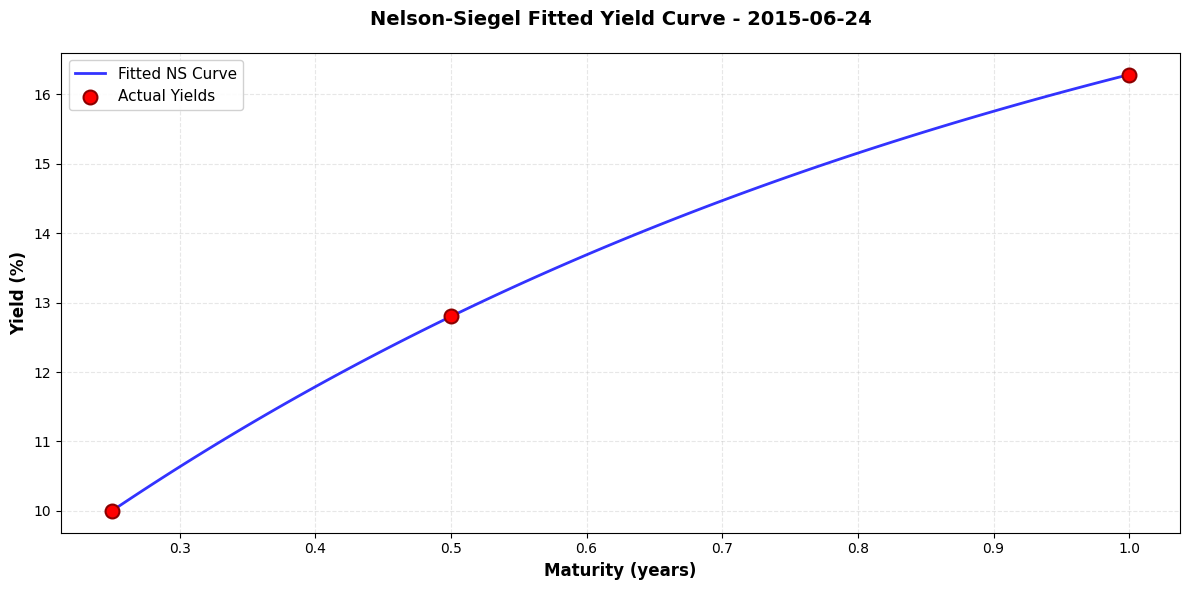

In [76]:
# Fit and plot the yield curve for a specific date
date_to_fit = '2015-07-01'

# Fit the Nelson-Siegel model
fitted_result = fit_ns_model(yield_curve_clean, date_to_fit)

# Plot the results
plot_fitted_yield_curve(yield_curve_clean, date_to_fit, fitted_result)


Nelson-Siegel Model Fit Summary for 2024-03-13
β₀ (Level):        680.1503  (Long-term yield level)
β₁ (Slope):       -665.9792  (Short-term slope)
β₂ (Curvature):    680.0226  (Medium-term hump)
λ  (Decay):          0.0101  (Decay rate)
RMSE:              0.403765  (Fit quality)
Optimization:    Success



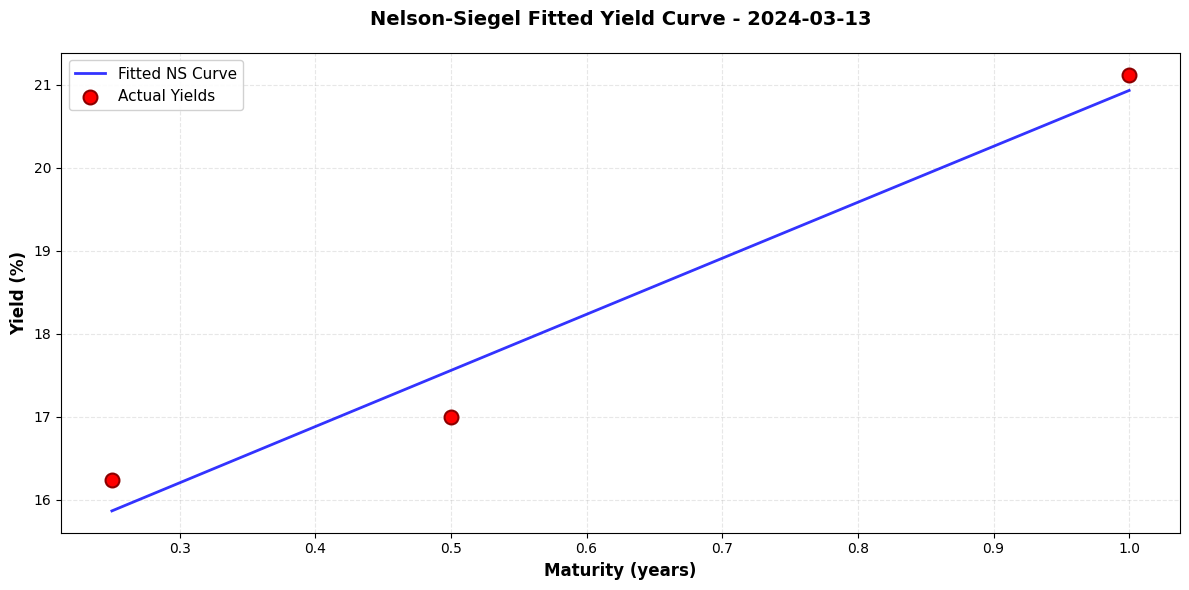

In [79]:
# Fit and plot the yield curve for a specific date
date_to_fit = '2024-03-13'

# Fit the Nelson-Siegel model
fitted_result = fit_ns_model(yield_curve_clean, date_to_fit)

# Plot the results
plot_fitted_yield_curve(yield_curve_clean, date_to_fit, fitted_result)


In [80]:
def standardize_yields(yields):

    # Calculate means and standard deviations for each yield column
    yield_means = yields.mean()
    yield_stds = yields.std()

    # Apply standardization formula: Z = (X - μ) / σ
    standardized_yields = (yields - yield_means) / yield_stds

    return standardized_yields

In [87]:
def compute_pca_variance_explained(standardized_yields):

    # 1. Drop rows with NaN values.
    # This ensures that for the remaining rows, all values are non-NaN.
    standardized_yields_rows_cleaned = standardized_yields.dropna()

    # 2. Drop columns that have fewer than 2 observations after row cleaning.
    # (A column must have at least 2 values to compute variance/covariance)
    # count() returns non-NaN counts for each column.
    valid_columns_mask = standardized_yields_rows_cleaned.count() >= 2
    standardized_yields_final = standardized_yields_rows_cleaned.loc[:, valid_columns_mask]

    # 3. Check if there's enough data left for PCA
    if standardized_yields_final.empty or \
       standardized_yields_final.shape[0] < 2 or \
       standardized_yields_final.shape[1] < 2:
        raise ValueError("Not enough complete and valid data points (rows or columns) after cleaning to compute PCA.")

    # Calculate the covariance matrix
    cov_matrix = standardized_yields_final.cov()

    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Sort eigenvalues in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_indices]

    # Calculate total variance
    total_variance = np.sum(eigenvalues_sorted)

    # Calculate variance explained percentage
    variance_explained_pct = (eigenvalues_sorted / total_variance) * 100

    # Create DataFrame with proper index starting from 1
    n_components = len(eigenvalues_sorted)
    result_df = pd.DataFrame({
        'Eigenvalue': eigenvalues_sorted,
        'Variance Explained (%)': variance_explained_pct
    }, index=range(1, n_components + 1))

    return result_df

In [92]:
# Manually select a set of reliably dense columns for PCA
dense_columns = ['91D', '182D', '364D'] # Choose the 3 most consistently available short-term tenors

# Filter yield_curve_filled to include only these dense columns
yield_curve_dense = yield_curve_filled[dense_columns]

# Impute remaining NaNs for PCA. Interpolation first, then ffill/bfill to catch edges.
yield_curve_dense_imputed = yield_curve_dense.interpolate(method='linear', limit_direction='both', limit_area='inside')
yield_curve_dense_imputed = yield_curve_dense_imputed.ffill().bfill()

# Now standardize and compute PCA variance explained using the dense and imputed data
standardized_data = standardize_yields(yield_curve_dense_imputed)
pca_result = compute_pca_variance_explained(standardized_data)
pca_result

,Eigenvalue,Variance Explained (%)
1,2.474248,82.474933
2,0.475234,15.841135
3,0.050518,1.683932
